# 02: Defining the Long-Term Causal Estimand

Notebook 01 showed that KuaiRec can be organized as a sequential user-day panel. This notebook now turns that panel into a specific causal question. That step matters because long-term causal analysis can easily become vague: there are many possible exposure definitions, many future outcomes, and many tempting descriptive comparisons. A credible project should define the causal target before estimating it.

The problem handled here is: **which daily recommendation exposure should be treated as the intervention, and which future user behavior should be treated as the long-term outcome?**

In recommender systems, the short-term metric is often immediate engagement, such as click, watch, completion, like, or session depth. The long-term business question is broader. Does today's recommendation experience make the user more likely to return, consume more, or keep engaging over the next several days? This notebook creates that bridge. It compares candidate daily treatments and candidate future outcomes, checks their variation, checks whether they are usable in the sampled panel, and then selects one primary estimand for later causal modeling.

The selected estimand should be understood as a precise causal statement with a metric name, treatment rule, time horizon, and target population. By the end of this notebook, we want to be able to say something like:

> Among active KuaiRec user-days with enough prior history and future follow-up, what is the causal effect of receiving a high-watch-exposure day on the user's next 7 days of engagement?

This notebook sets up the estimand and outcome construction before effect estimation. Instead, it defines the treatment, outcome, population, and modeling table that later notebooks will use for inverse probability weighting, marginal structural models, and g-computation.


<!-- dataset-experiment-context -->
## Dataset and Sequential Design Context

This project uses KuaiRec interaction logs organized into a user-day panel. The raw data contain user-video interactions, watch behavior, user features, item metadata, and item daily popularity information.

The data come from a real observational sequential recommendation log. Daily exposure was created by the recommender system, so assignment must be treated as time-varying and confounded. The treatment is a constructed high-watch-exposure day, the primary outcome is future seven-day engagement, and lagged user behavior is both a predictor of treatment and a predictor of future outcomes.

The project studies a sequential causal question: whether short-term exposure is associated with later engagement after adjusting for observed history. Marginal structural models, g-computation, doubly robust estimation, overlap diagnostics, and heterogeneity checks are used to decide whether the evidence is strong enough to motivate a future online test.

**Role of this notebook.** This notebook defines the target estimand, treatment, outcome window, eligibility rules, and modeling panel before any effect estimator is fit.

<!-- mathematical-setup -->

## Mathematical Setup

Long-term outcomes require a clear time index. If treatment is measured on day \(t\), a future outcome window can be written as

$$
Y^{(h_1,h_2)}_{it}=\sum_{k=h_1}^{h_2} g_{i,t+k},
$$

where \(g_{i,t+k}\) is an engagement measure such as future interactions or watch time. A windowed average can also be used when users have different amounts of observable follow-up:

$$
\bar Y^{(h_1,h_2)}_{it}=\frac{1}{h_2-h_1+1}\sum_{k=h_1}^{h_2} g_{i,t+k}.
$$

The treatment must be defined before the outcome window starts, so the design avoids using post-treatment information in the adjustment set. The same causal design can answer different product questions depending on \(Y\). A short horizon captures immediate response, while a longer horizon is closer to retention or habit formation.


### What This Step Decides

The notebook makes four design decisions.

1. **Candidate treatments**: compare several daily exposure patterns, such as high-intensity days and high-watch-exposure days.
2. **Candidate outcomes**: compare future activity metrics over 1-day, 3-day, and 7-day horizons.
3. **Analysis population**: restrict to rows where treatment is meaningful and future outcomes can be observed.
4. **Primary estimand**: choose one treatment-outcome pair as the main causal target for the rest of the long-term causal effects workflow.

This is the notebook where we deliberately avoid the common mistake of jumping straight into a model. A causal model is only useful after the target question is clean.


#### Important Modeling Language

The rest of the notebook uses the following causal vocabulary:

| Term | Meaning in this project |
|---|---|
| Unit | A `user_id` observed on a specific `event_date`. |
| Time step | One calendar day. |
| Treatment | A daily exposure pattern derived from that day's recommendation consumption. |
| Control condition | An active user-day that falls below the treatment rule. |
| Outcome | Future user behavior after the treatment day, such as future interactions or active days. |
| Baseline/history state | Pre-treatment behavior such as yesterday's activity and prior 3-day engagement. |
| Estimand | The causal effect we want to estimate for a defined population, treatment, comparator, and outcome. |

The distinction between **treatment** and **outcome** is especially important. Today's engagement pattern can be treated as exposure, but tomorrow's engagement must remain future outcome. Mixing those up would leak post-treatment information into the adjustment set.


#### Setup

The first code cell imports the libraries used for metric summaries, visual diagnostics, and saving the final modeling table. The notebook uses only standard data science libraries so that the output remains easy to rerun.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")


The notebook environment is ready for estimand design. The libraries support tabular summaries, plots, and saved artifacts. The next step is to load the processed panel from Notebook 01 so this notebook can focus on causal definitions.


#### Locate the Processed Panel

Notebook 01 saved a dense user-day panel to `data/processed`. This notebook loads that file directly. Keeping this boundary clean makes the project sequence easier to follow. Notebook 01 handles raw data understanding; Notebook 02 handles causal target definition.


In [2]:
PROCESSED_PANEL_RELATIVE_PATH = Path("data/processed/kuairec_user_day_panel_sample.parquet")

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / PROCESSED_PANEL_RELATIVE_PATH).exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not find {PROCESSED_PANEL_RELATIVE_PATH}. Run Notebook 01 first or run this notebook inside the project."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PANEL_PATH = PROJECT_ROOT / PROCESSED_PANEL_RELATIVE_PATH

print(f"Project root: {PROJECT_ROOT}")
print(f"Input panel: {PANEL_PATH}")
print(f"Processed output folder: {PROCESSED_DIR}")


The printed paths confirm that Notebook 01's processed panel is available. This creates a clean workflow boundary: the current notebook can start from a user-day panel and spend its attention on treatment, outcome, and population choices.


#### Load the User-Day Panel

The next cell loads the panel created in Notebook 01. Each row is a user-day. The table already contains daily engagement summaries, lagged history features, candidate treatment indicators, and future outcome columns.


In [3]:
user_day = pd.read_parquet(PANEL_PATH)
user_day["event_date"] = pd.to_datetime(user_day["event_date"])
user_day = user_day.sort_values(["user_id", "event_date"]).reset_index(drop=True)

print(f"Panel shape: {user_day.shape}")
print(f"Users: {user_day['user_id'].nunique():,}")
print(f"Dates: {user_day['event_date'].nunique():,}")
display(user_day.head())


Panel shape: (5733, 58)
Users: 91
Dates: 63


,user_id,event_date,interactions,unique_videos,total_play_duration_ms,avg_play_duration_ms,avg_video_duration_ms,avg_watch_ratio,high_watch_count,complete_or_rewatch_count,total_play_duration_sec,avg_play_duration_sec,avg_video_duration_sec,high_watch_share,complete_or_rewatch_share,active_day,lag_1_active_day,prior_3day_active_day,lag_1_interactions,prior_3day_interactions,lag_1_total_play_duration_sec,prior_3day_total_play_duration_sec,lag_1_avg_watch_ratio,prior_3day_avg_watch_ratio,lag_1_high_watch_share,prior_3day_high_watch_share,lead_1_active_day,lead_2_active_day,lead_3_active_day,lead_4_active_day,lead_5_active_day,lead_6_active_day,lead_7_active_day,lead_1_interactions,lead_2_interactions,lead_3_interactions,lead_4_interactions,lead_5_interactions,lead_6_interactions,lead_7_interactions,lead_1_total_play_duration_sec,lead_2_total_play_duration_sec,lead_3_total_play_duration_sec,lead_4_total_play_duration_sec,lead_5_total_play_duration_sec,lead_6_total_play_duration_sec,lead_7_total_play_duration_sec,next_day_active,next_day_interactions,next_day_play_duration_sec,future_3day_active_days,future_3day_interactions,future_3day_play_duration_sec,future_7day_active_days,future_7day_interactions,future_7day_play_duration_sec,treatment_high_intensity,treatment_high_watch_exposure
0,14,2020-07-05,26.0000,26.0000,"240,975.0000","9,268.2692","10,187.6538",1.0845,15.0000,12.0000,240.9750,9.2683,10.1877,0.5769,0.4615,1,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,23.0000,78.0000,22.0000,55.0000,52.0000,32.0000,42.0000,248.3440,655.4890,201.9010,485.0390,606.2440,284.7470,337.9180,1.0000,23.0000,248.3440,3.0000,123.0000,"1,105.7340",7.0000,304.0000,"2,819.6820",0,1
1,14,2020-07-06,23.0000,23.0000,"248,344.0000","10,797.5652","14,615.2174",1.0640,12.0000,10.0000,248.3440,10.7976,14.6152,0.5217,0.4348,1,1.0000,1.0000,26.0000,26.0000,240.9750,240.9750,1.0845,1.0845,0.5769,0.5769,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,78.0000,22.0000,55.0000,52.0000,32.0000,42.0000,46.0000,655.4890,201.9010,485.0390,606.2440,284.7470,337.9180,502.1450,1.0000,78.0000,655.4890,3.0000,155.0000,"1,342.4290",7.0000,327.0000,"3,073.4830",0,1
2,14,2020-07-07,78.0000,78.0000,"655,489.0000","8,403.7051","13,529.6410",0.8415,36.0000,27.0000,655.4890,8.4037,13.5296,0.4615,0.3462,1,1.0000,2.0000,23.0000,49.0000,248.3440,489.3190,1.0640,2.1485,0.5217,1.0987,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,22.0000,55.0000,52.0000,32.0000,42.0000,46.0000,42.0000,201.9010,485.0390,606.2440,284.7470,337.9180,502.1450,337.4890,1.0000,22.0000,201.9010,3.0000,129.0000,"1,293.1840",7.0000,291.0000,"2,755.4830",1,0
3,14,2020-07-08,22.0000,22.0000,"201,901.0000","9,177.3182","12,657.1818",0.9828,11.0000,9.0000,201.9010,9.1773,12.6572,0.5000,0.4091,1,1.0000,3.0000,78.0000,127.0000,655.4890,"1,144.8080",0.8415,2.9900,0.4615,1.5602,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,55.0000,52.0000,32.0000,42.0000,46.0000,42.0000,10.0000,485.0390,606.2440,284.7470,337.9180,502.1450,337.4890,146.5620,1.0000,55.0000,485.0390,3.0000,139.0000,"1,376.0300",7.0000,279.0000,"2,700.1440",0,1
4,14,2020-07-09,55.0000,55.0000,"485,039.0000","8,818.8909","12,841.6727",0.8619,20.0000,15.0000,485.0390,8.8189,12.8417,0.3636,0.2727,1,1.0000,3.0000,22.0000,123.0000,201.9010,"1,105.7340",0.9828,2.8883,0.5000,1.4833,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,52.0000,32.0000,42.0000,46.0000,42.0000,10.0000,87.0000,606.2440,284.7470,337.9180,502.1450,337.4890,146.5620,857.2160,1.0000,52.0000,606.2440,3.0000,126.0000,"1,228.9090",7.0000,311.0000,"3,072.3210",0,0


The panel shape and preview confirm that each row is a user-day with current behavior, history variables, treatments, and future outcomes. With this structure loaded, the notebook can now define which columns should be used for the primary causal question.


#### Field Guide for the Processed Panel

The processed panel has many columns because it combines current-day behavior, prior behavior, candidate treatments, and future outcomes. The next table groups the most important columns into modeling roles. This makes the rest of the notebook easier to read because every metric is tied to a causal purpose.


In [4]:
panel_field_guide = pd.DataFrame(
    [
        {"role": "identifier", "columns": "user_id, event_date", "description": "Define the user-day unit and time step."},
        {"role": "current-day behavior", "columns": "active_day, interactions, total_play_duration_sec, avg_watch_ratio", "description": "Describe what happened on the current day before creating treatment labels."},
        {"role": "daily exposure quality", "columns": "high_watch_share, complete_or_rewatch_share", "description": "Measure the share of consumed videos with high watch ratio or over-completion."},
        {"role": "history / confounders", "columns": "lag_1_*, prior_3day_*", "description": "Pre-treatment user state. These variables may affect both today's treatment and future outcomes."},
        {"role": "future outcomes", "columns": "next_day_*, future_3day_*, future_7day_*", "description": "Behavior after the current day. These are candidate long-term outcomes."},
        {"role": "existing treatment candidates", "columns": "treatment_high_intensity, treatment_high_watch_exposure", "description": "First-pass treatment labels created in Notebook 01."},
    ]
)

display(panel_field_guide)


,role,columns,description
0,identifier,"user_id, event_date",Define the user-day unit and time step.
1,current-day behavior,"active_day, interactions, total_play_duration_...",Describe what happened on the current day befo...
2,daily exposure quality,"high_watch_share, complete_or_rewatch_share",Measure the share of consumed videos with high...
3,history / confounders,"lag_1_*, prior_3day_*",Pre-treatment user state. These variables may ...
4,future outcomes,"next_day_*, future_3day_*, future_7day_*",Behavior after the current day. These are cand...
5,existing treatment candidates,"treatment_high_intensity, treatment_high_watch...",First-pass treatment labels created in Noteboo...


The field guide separates identifiers, current-day behavior, histories, treatments, and outcomes. This separation protects the causal design from leakage: future outcomes should stay separate from adjustment variables, and treatment-day summaries should remain distinct from baseline history.


#### Basic Panel Sanity Check

Before choosing an estimand, we check the panel's size, date range, and activity rate. This gives context for what kinds of outcomes are feasible. If nearly everyone is active every day, for example, a binary next-day retention outcome may have too little variation to be the primary outcome.


In [5]:
panel_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(user_day)},
        {"metric": "users", "value": user_day["user_id"].nunique()},
        {"metric": "dates", "value": user_day["event_date"].nunique()},
        {"metric": "first_date", "value": user_day["event_date"].min()},
        {"metric": "last_date", "value": user_day["event_date"].max()},
        {"metric": "active_day_rate", "value": user_day["active_day"].mean()},
        {"metric": "mean_daily_interactions", "value": user_day["interactions"].mean()},
        {"metric": "mean_daily_watch_minutes", "value": user_day["total_play_duration_sec"].mean() / 60},
    ]
)

display(panel_summary)


,metric,value
0,rows,5733
1,users,91
2,dates,63
3,first_date,2020-07-05 00:00:00
4,last_date,2020-09-05 00:00:00
5,active_day_rate,0.9658
6,mean_daily_interactions,50.4197
7,mean_daily_watch_minutes,7.3176


The sanity check gives the scale and activity level of the analysis panel. The high active-day rate hints that binary retention may have a ceiling effect, so the notebook next creates follow-up flags and compares richer outcome definitions.


#### Add Calendar and Follow-Up Flags

A future 7-day outcome is only valid if the row has 7 days of future data in the panel. Similarly, a history-adjusted analysis is cleaner if each row has at least a few prior days of observed history. The next cell creates day-index, history, and follow-up flags.

These flags will later define the analysis population. This is one of the most important safeguards in the notebook: we want to avoid comparing rows with full follow-up against rows at the edge of the panel where future activity is unknown.


In [6]:
user_day["panel_day_index"] = user_day.groupby("user_id").cumcount()
user_day["max_panel_day_index"] = user_day.groupby("user_id")["panel_day_index"].transform("max")
user_day["days_until_panel_end"] = user_day["max_panel_day_index"] - user_day["panel_day_index"]
user_day["day_of_week"] = user_day["event_date"].dt.day_name()
user_day["calendar_day_index"] = (user_day["event_date"] - user_day["event_date"].min()).dt.days

user_day["has_1day_followup"] = user_day["days_until_panel_end"] >= 1
user_day["has_3day_followup"] = user_day["days_until_panel_end"] >= 3
user_day["has_7day_followup"] = user_day["days_until_panel_end"] >= 7
user_day["has_3day_history"] = user_day["panel_day_index"] >= 3

followup_summary = user_day[
    ["has_1day_followup", "has_3day_followup", "has_7day_followup", "has_3day_history"]
].mean().rename("share_of_rows").reset_index().rename(columns={"index": "flag"})

display(followup_summary)


,flag,share_of_rows
0,has_1day_followup,0.9841
1,has_3day_followup,0.9524
2,has_7day_followup,0.8889
3,has_3day_history,0.9524


The follow-up and history flags tell us which rows can support a fair future-outcome comparison. Rows at the beginning lack enough history, and rows near the end lack enough future observation, so these flags will become part of the final analysis-population definition.


#### Create Additional Candidate Treatment Definitions

Notebook 01 already created two treatment candidates. This cell adds two more transparent candidates so we can compare options before choosing the primary treatment.

- `treatment_high_intensity`: active day with unusually many interactions.
- `treatment_high_watch_exposure`: active day with a high share of videos watched at least 80 percent.
- `treatment_overcompletion_exposure`: active day with a high share of complete or over-complete watches.
- `treatment_high_watch_time`: active day with unusually high total watch time.

The goal is to choose a treatment definition with enough variation, enough treated days, and a clear connection to the substantive question. The goal is to choose the one that best matches the causal question and has enough variation.


In [7]:
# Create additional candidate treatment definitions.
active_days = user_day["active_day"].eq(1)

overcompletion_threshold = user_day.loc[active_days, "complete_or_rewatch_share"].median()
watch_time_threshold = user_day.loc[active_days, "total_play_duration_sec"].quantile(0.75)

user_day["treatment_overcompletion_exposure"] = (
    active_days & (user_day["complete_or_rewatch_share"] >= overcompletion_threshold)
).astype(int)

user_day["treatment_high_watch_time"] = (
    active_days & (user_day["total_play_duration_sec"] >= watch_time_threshold)
).astype(int)

candidate_treatments = [
    "treatment_high_intensity",
    "treatment_high_watch_exposure",
    "treatment_overcompletion_exposure",
    "treatment_high_watch_time",
]

treatment_rules = pd.DataFrame(
    [
        {
            "treatment": "treatment_high_intensity",
            "plain_english_rule": "Active day with interaction count in the upper quartile of active days.",
            "threshold_or_definition": "Created in Notebook 01",
        },
        {
            "treatment": "treatment_high_watch_exposure",
            "plain_english_rule": "Active day with high-watch share at or above the active-day median.",
            "threshold_or_definition": "Created in Notebook 01",
        },
        {
            "treatment": "treatment_overcompletion_exposure",
            "plain_english_rule": "Active day with complete-or-rewatch share at or above the active-day median.",
            "threshold_or_definition": overcompletion_threshold,
        },
        {
            "treatment": "treatment_high_watch_time",
            "plain_english_rule": "Active day with total watch time in the upper quartile of active days.",
            "threshold_or_definition": watch_time_threshold,
        },
    ]
)

display(treatment_rules)


,treatment,plain_english_rule,threshold_or_definition
0,treatment_high_intensity,Active day with interaction count in the upper...,Created in Notebook 01
1,treatment_high_watch_exposure,Active day with high-watch share at or above t...,Created in Notebook 01
2,treatment_overcompletion_exposure,Active day with complete-or-rewatch share at o...,0.3148
3,treatment_high_watch_time,Active day with total watch time in the upper ...,608.0240


The treatment-rule table expands the choice set from Notebook 01. By defining several plausible exposure patterns before looking at the final estimand, the notebook makes the treatment choice explicit.


### Candidate Treatment Variation

A usable treatment needs variation. If almost every active user-day is treated or almost none are treated, causal estimation becomes unstable or uninformative. This cell summarizes treatment prevalence across all user-days and across active user-days only.


In [8]:
treatment_summary_rows = []
for treatment in candidate_treatments:
    treatment_summary_rows.append(
        {
            "treatment": treatment,
            "share_all_user_days": user_day[treatment].mean(),
            "share_active_user_days": user_day.loc[active_days, treatment].mean(),
            "treated_user_days": int(user_day[treatment].sum()),
            "treated_users": int(user_day.loc[user_day[treatment].eq(1), "user_id"].nunique()),
            "untreated_active_user_days": int((active_days & user_day[treatment].eq(0)).sum()),
            "users_with_both_treated_and_control_days": int(
                user_day.groupby("user_id")[treatment].nunique().eq(2).sum()
            ),
        }
    )

treatment_summary = pd.DataFrame(treatment_summary_rows)
display(treatment_summary)


,treatment,share_all_user_days,share_active_user_days,treated_user_days,treated_users,untreated_active_user_days,users_with_both_treated_and_control_days
0,treatment_high_intensity,0.2501,0.2590,1434,91,4103,91
1,treatment_high_watch_exposure,0.4842,0.5014,2776,91,2761,91
2,treatment_overcompletion_exposure,0.4837,0.5008,2773,91,2764,91
3,treatment_high_watch_time,0.2416,0.2501,1385,91,4152,91


The treatment summary shows whether each candidate has enough treated and control examples, including within-user variation. This is a practical positivity check: a treatment with little variation would be difficult to model credibly.


#### Visualize Treatment Rates Over Time

The treatment rate should be spread across dates with no single short window dominating the contrast. The next plot shows daily prevalence for each candidate treatment. Stable, non-constant variation is useful because it leaves room for causal estimators to compare treated and untreated days across similar histories.


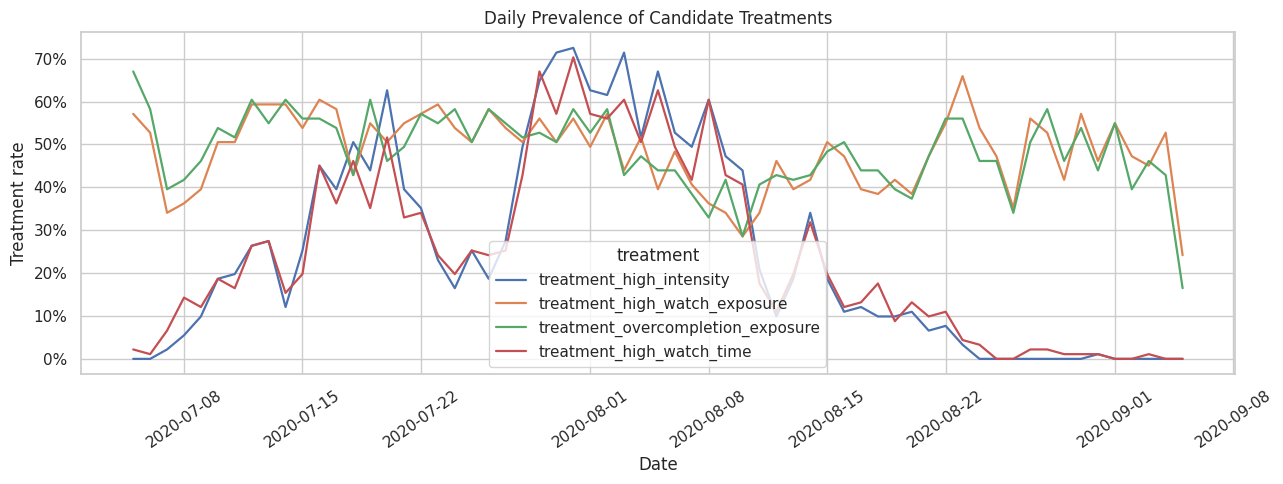

In [9]:
daily_treatment_rates = (
    user_day.groupby("event_date")[candidate_treatments]
    .mean()
    .reset_index()
    .melt(id_vars="event_date", var_name="treatment", value_name="daily_rate")
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(
    data=daily_treatment_rates,
    x="event_date",
    y="daily_rate",
    hue="treatment",
    linewidth=1.6,
    ax=ax,
)
ax.set_title("Daily Prevalence of Candidate Treatments")
ax.set_xlabel("Date")
ax.set_ylabel("Treatment rate")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


The daily treatment-rate plot reveals whether treatment definitions are stable over the sample window or tied to calendar trends. This motivates keeping calendar time in the later modeling table as a possible adjustment variable.


#### Add Outcome Variants for Interpretability

The raw future outcomes are useful, but a few transformed versions make interpretation easier. This cell creates average daily future interactions and future watch hours. It also creates log-transformed outcomes for skewed engagement volume metrics.

The raw count outcome remains the main candidate because it is directly interpretable: how many interactions occur in the next 7 days?


In [10]:
user_day["future_3day_avg_daily_interactions"] = user_day["future_3day_interactions"] / 3
user_day["future_7day_avg_daily_interactions"] = user_day["future_7day_interactions"] / 7
user_day["future_3day_play_hours"] = user_day["future_3day_play_duration_sec"] / 3_600
user_day["future_7day_play_hours"] = user_day["future_7day_play_duration_sec"] / 3_600
user_day["log1p_future_7day_interactions"] = np.log1p(user_day["future_7day_interactions"])
user_day["log1p_future_7day_play_duration_sec"] = np.log1p(user_day["future_7day_play_duration_sec"])

candidate_outcomes = [
    "next_day_active",
    "future_3day_active_days",
    "future_7day_active_days",
    "future_3day_interactions",
    "future_7day_interactions",
    "future_7day_avg_daily_interactions",
    "future_7day_play_hours",
    "log1p_future_7day_interactions",
]

print("Created candidate outcome variants:")
for outcome in candidate_outcomes:
    print(f"- {outcome}")


Created candidate outcome variants:
- next_day_active
- future_3day_active_days
- future_7day_active_days
- future_3day_interactions
- future_7day_interactions
- future_7day_avg_daily_interactions
- future_7day_play_hours
- log1p_future_7day_interactions


The created outcomes turn raw future behavior into several interpretable targets: retention-like activity counts, interaction volume, watch hours, and log-transformed engagement. The next cell compares these candidates to decide which one is best suited as the primary outcome.


### Candidate Outcomes

A primary long-term outcome should have enough variation, low missingness after applying follow-up rules, and a clear interpretation. The next table compares candidate outcomes on missingness, mean, standard deviation, and the share of rows at the maximum value.

The maximum-share column is especially important for active-day outcomes. If most rows are at the maximum, the outcome has a ceiling effect and may be weak as a primary metric.


In [11]:
outcome_summary_rows = []
for outcome in candidate_outcomes:
    values = user_day[outcome]
    nonmissing = values.dropna()
    outcome_summary_rows.append(
        {
            "outcome": outcome,
            "missing_rate": values.isna().mean(),
            "mean": nonmissing.mean(),
            "std": nonmissing.std(),
            "min": nonmissing.min(),
            "p25": nonmissing.quantile(0.25),
            "median": nonmissing.median(),
            "p75": nonmissing.quantile(0.75),
            "max": nonmissing.max(),
            "share_at_zero": (nonmissing == 0).mean(),
            "share_at_max": (nonmissing == nonmissing.max()).mean(),
            "unique_values": nonmissing.nunique(),
        }
    )

outcome_summary = pd.DataFrame(outcome_summary_rows)
display(outcome_summary)


,outcome,missing_rate,mean,std,min,p25,median,p75,max,share_at_zero,share_at_max,unique_values
0,next_day_active,0.0159,0.9661,0.1809,0.0000,1.0000,1.0000,1.0000,1.0000,0.0339,0.9661,2
1,future_3day_active_days,0.0476,2.9117,0.3841,0.0000,3.0000,3.0000,3.0000,3.0000,0.0073,0.9379,4
2,future_7day_active_days,0.1111,6.8055,0.7406,0.0000,7.0000,7.0000,7.0000,7.0000,0.0051,0.8966,8
3,future_3day_interactions,0.0476,156.2579,80.1244,0.0000,99.0000,153.0000,209.0000,581.0000,0.0073,0.0002,398
4,future_7day_interactions,0.1111,377.9823,155.8725,0.0000,275.0000,383.0000,489.0000,956.0000,0.0051,0.0002,691
5,future_7day_avg_daily_interactions,0.1111,53.9975,22.2675,0.0000,39.2857,54.7143,69.8571,136.5714,0.0051,0.0002,691
6,future_7day_play_hours,0.1111,0.9122,0.4294,0.0000,0.6202,0.8982,1.1665,3.2961,0.0051,0.0002,5061
7,log1p_future_7day_interactions,0.1111,5.8030,0.6652,0.0000,5.6204,5.9506,6.1944,6.8638,0.0051,0.0002,691


The outcome summary compares missingness, variation, and ceiling effects. Outcomes with low variation are still useful as secondary checks, but the primary outcome should give the model enough signal to distinguish future engagement across user-days.


#### Visualize Future Outcome Distributions

This cell plots the most important future outcome candidates. The active-days outcome is bounded between 0 and 7, while interaction volume and watch hours are continuous or count-like engagement measures. Seeing them together makes the tradeoff visible: retention-style outcomes are easy to explain, but in this sample they may have less variation than engagement-volume outcomes.


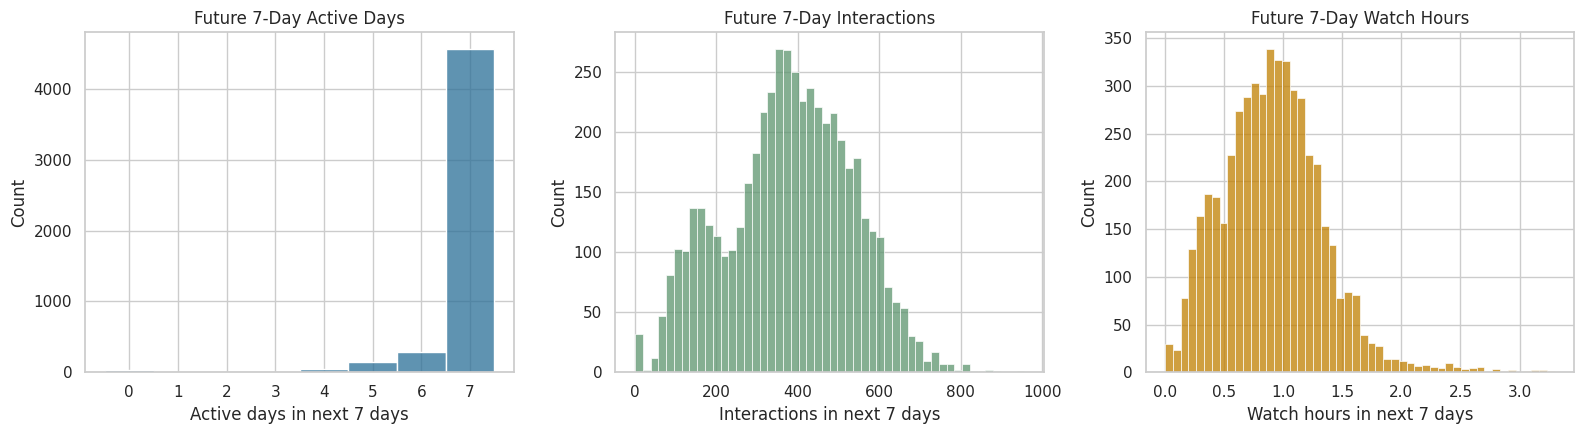

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(data=user_day, x="future_7day_active_days", bins=np.arange(-0.5, 8.5, 1), ax=axes[0], color="#2A6F97")
axes[0].set_title("Future 7-Day Active Days")
axes[0].set_xlabel("Active days in next 7 days")

sns.histplot(data=user_day, x="future_7day_interactions", bins=50, ax=axes[1], color="#5C946E")
axes[1].set_title("Future 7-Day Interactions")
axes[1].set_xlabel("Interactions in next 7 days")

sns.histplot(data=user_day, x="future_7day_play_hours", bins=50, ax=axes[2], color="#C07F00")
axes[2].set_title("Future 7-Day Watch Hours")
axes[2].set_xlabel("Watch hours in next 7 days")

plt.tight_layout()
plt.show()


The distributions make the outcome tradeoff visible. Future active days are easy to explain but bounded, while future interactions and watch hours contain richer variation for modeling long-term engagement.


### Retention Ceiling Effect

Next-day and 7-day active outcomes are intuitively appealing because they sound like retention. However, the sampled panel is very active. If nearly all rows have next-day activity or full 7-day activity, then a retention outcome cannot distinguish users well.

This cell quantifies that ceiling effect. The result keeps retention secondary; it tells us retention should be secondary in this sample, while a richer engagement outcome may be better as the primary outcome.


In [13]:
retention_ceiling = pd.DataFrame(
    [
        {
            "outcome": "next_day_active",
            "available_rows": user_day["next_day_active"].notna().sum(),
            "mean": user_day["next_day_active"].mean(),
            "share_at_max": (user_day["next_day_active"] == 1).mean(),
        },
        {
            "outcome": "future_3day_active_days",
            "available_rows": user_day["future_3day_active_days"].notna().sum(),
            "mean": user_day["future_3day_active_days"].mean(),
            "share_at_max": (user_day["future_3day_active_days"] == 3).mean(),
        },
        {
            "outcome": "future_7day_active_days",
            "available_rows": user_day["future_7day_active_days"].notna().sum(),
            "mean": user_day["future_7day_active_days"].mean(),
            "share_at_max": (user_day["future_7day_active_days"] == 7).mean(),
        },
    ]
)

display(retention_ceiling)


,outcome,available_rows,mean,share_at_max
0,next_day_active,5642,0.9661,0.9508
1,future_3day_active_days,5460,2.9117,0.8932
2,future_7day_active_days,5096,6.8055,0.7970


The ceiling-effect table confirms that retention-style outcomes are highly saturated in this sample. This supports using future 7-day interactions as the primary outcome while keeping active-days metrics as secondary product-health checks.


#### Naive Treatment-Outcome Associations

The next table compares treated and untreated active user-days for each treatment-outcome pair. This is still descriptive. It is a diagnostic table that helps us understand whether a candidate estimand produces an interpretable contrast.

A large difference here may reflect confounding, selection, or genuine treatment effects. Later notebooks will try to adjust for confounding. Here we only use the table to compare candidate definitions.


In [14]:
# Naive treatment-Outcome associations.
def summarize_naive_difference(data, treatment_col, outcome_col):
    """
    Summarize one naive treated-control outcome difference.
    
    Idea
    ----
    The helper records the unadjusted comparison for the selected outcome before propensity, MSM, or g-computation adjustments are introduced.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    outcome_col : object
        Outcome column used in the estimator.
    
    Returns
    -------
    pandas.DataFrame
        Naive treated-control difference and group summaries.
    """
    subset = data.loc[data["active_day"].eq(1)].dropna(subset=[treatment_col, outcome_col]).copy()
    grouped = subset.groupby(treatment_col)[outcome_col].agg(["mean", "count", "std"])
    if not set(grouped.index) >= {0, 1}:
        return None

    control_mean = grouped.loc[0, "mean"]
    treated_mean = grouped.loc[1, "mean"]
    return {
        "treatment": treatment_col,
        "outcome": outcome_col,
        "control_mean": control_mean,
        "treated_mean": treated_mean,
        "difference": treated_mean - control_mean,
        "relative_lift": (treated_mean / control_mean - 1) if control_mean != 0 else np.nan,
        "control_days": grouped.loc[0, "count"],
        "treated_days": grouped.loc[1, "count"],
    }

naive_rows = []
for treatment in candidate_treatments:
    for outcome in candidate_outcomes:
        row = summarize_naive_difference(user_day, treatment, outcome)
        if row is not None:
            naive_rows.append(row)

naive_associations = pd.DataFrame(naive_rows)

display(
    naive_associations.sort_values(["outcome", "treatment"])
)


,treatment,outcome,control_mean,treated_mean,difference,relative_lift,control_days,treated_days
1,treatment_high_intensity,future_3day_active_days,2.9371,2.9477,0.0106,0.0036,3880,1434
9,treatment_high_watch_exposure,future_3day_active_days,2.9479,2.9321,-0.0158,-0.0054,2649,2665
25,treatment_high_watch_time,future_3day_active_days,2.9377,2.9465,0.0089,0.0030,3930,1384
17,treatment_overcompletion_exposure,future_3day_active_days,2.9450,2.9350,-0.0100,-0.0034,2637,2677
3,treatment_high_intensity,future_3day_interactions,138.8616,207.0342,68.1726,0.4909,3880,1434
11,treatment_high_watch_exposure,future_3day_interactions,157.7493,156.7700,-0.9794,-0.0062,2649,2665
27,treatment_high_watch_time,future_3day_interactions,141.6537,201.5686,59.9150,0.4230,3930,1384
19,treatment_overcompletion_exposure,future_3day_interactions,156.8654,157.6451,0.7797,0.0050,2637,2677
2,treatment_high_intensity,future_7day_active_days,6.8580,6.8562,-0.0017,-0.0003,3528,1433
10,treatment_high_watch_exposure,future_7day_active_days,6.8719,6.8430,-0.0289,-0.0042,2483,2478


The naive association table helps compare candidate treatment-outcome pairs, but it is still descriptive. The table points toward promising contrasts; the next cells examine whether those contrasts are confounded by prior user behavior.


#### Visualize Candidate Treatment Effects Descriptively

This plot focuses on future 7-day interactions because that is the strongest primary-outcome candidate. Again, this is descriptive. The purpose is to compare treatment definitions before causal effect estimation begins.


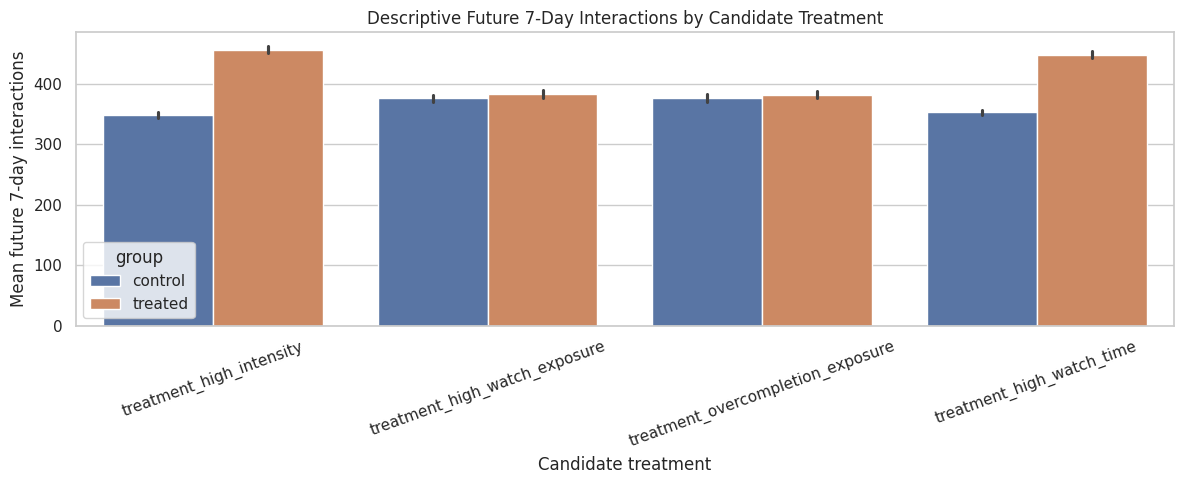

In [15]:
plot_df = user_day.loc[user_day["active_day"].eq(1), candidate_treatments + ["future_7day_interactions"]].copy()
plot_df = plot_df.melt(
    id_vars="future_7day_interactions",
    value_vars=candidate_treatments,
    var_name="treatment",
    value_name="treated",
)
plot_df["group"] = np.where(plot_df["treated"].eq(1), "treated", "control")

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=plot_df.dropna(subset=["future_7day_interactions"]),
    x="treatment",
    y="future_7day_interactions",
    hue="group",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_title("Descriptive Future 7-Day Interactions by Candidate Treatment")
ax.set_xlabel("Candidate treatment")
ax.set_ylabel("Mean future 7-day interactions")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


The bar plot focuses attention on future 7-day interactions and shows how treated and control means differ for each candidate treatment. Because these are unadjusted means, they are best used to choose a coherent estimand.


### Pre-Treatment Imbalance

A candidate treatment is more credible if we can model its assignment using observed pre-treatment history. The next cell measures how different treated and untreated active days are before treatment occurs.

The standardized mean difference compares treated and control means in standard deviation units. Large imbalances are expected in recommender logs, and they are a warning that naive comparisons need adjustment.


In [16]:
# Check pre-Treatment imbalance.
pre_treatment_covariates = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "lag_1_high_watch_share",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_avg_watch_ratio",
    "prior_3day_high_watch_share",
    "calendar_day_index",
]

def standardized_mean_differences(data, treatment_col, covariate_cols):
    """
    Compute standardized mean differences for several covariates.
    
    Idea
    ----
    This summarizes observed treated-control imbalance across the covariates used for adjustment in the sequential causal panel.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    treatment_col : object
        Column indicating treatment or exposure status.
    covariate_cols : object
        Covariate columns to summarize for balance.
    
    Returns
    -------
    pandas.DataFrame
        One row per covariate with treated means, control means, and standardized differences.
    """
    analytic = data.loc[data["active_day"].eq(1)].dropna(subset=[treatment_col]).copy()
    rows = []
    for covariate in covariate_cols:
        treated = analytic.loc[analytic[treatment_col].eq(1), covariate].dropna()
        control = analytic.loc[analytic[treatment_col].eq(0), covariate].dropna()
        pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
        rows.append(
            {
                "treatment": treatment_col,
                "covariate": covariate,
                "treated_mean": treated.mean(),
                "control_mean": control.mean(),
                "smd": (treated.mean() - control.mean()) / pooled_sd if pooled_sd and not np.isnan(pooled_sd) else np.nan,
            }
        )
    return pd.DataFrame(rows)

balance_tables = [
    standardized_mean_differences(user_day, treatment, pre_treatment_covariates)
    for treatment in candidate_treatments
]
confounding_balance = pd.concat(balance_tables, ignore_index=True)

display(
    confounding_balance.assign(abs_smd=confounding_balance["smd"].abs())
    .sort_values(["treatment", "abs_smd"], ascending=[True, False])
    .drop(columns="abs_smd")
)


,treatment,covariate,treated_mean,control_mean,smd
6,treatment_high_intensity,prior_3day_interactions,207.7497,134.4448,1.0026
1,treatment_high_intensity,lag_1_interactions,71.7364,44.2764,0.8406
7,treatment_high_intensity,prior_3day_total_play_duration_sec,"1,794.1988","1,177.3717",0.8370
2,treatment_high_intensity,lag_1_total_play_duration_sec,617.3946,388.2157,0.7200
10,treatment_high_intensity,calendar_day_index,24.7789,32.7007,-0.5046
5,treatment_high_intensity,prior_3day_active_day,2.9303,2.8279,0.2198
9,treatment_high_intensity,prior_3day_high_watch_share,1.4207,1.3741,0.1029
0,treatment_high_intensity,lag_1_active_day,0.9770,0.9654,0.0694
8,treatment_high_intensity,prior_3day_avg_watch_ratio,2.7440,2.6835,0.0556
3,treatment_high_intensity,lag_1_avg_watch_ratio,0.9103,0.9208,-0.0193


The balance table shows how much treated and control user-days differ before treatment. These imbalances are the reason the project needs causal methods in later notebooks.


#### Visualize Confounding by Candidate Treatment

This heatmap shows which treatment definitions are most strongly associated with prior user state. No treatment definition will be perfectly randomized here. The point is to understand what adjustment will need to handle in later notebooks.


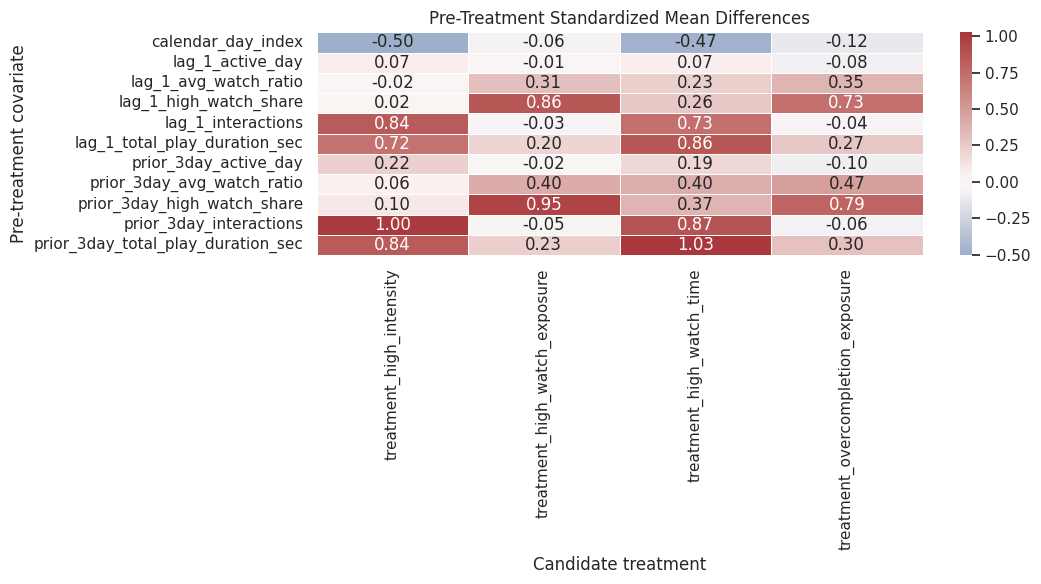

In [17]:
balance_heatmap = confounding_balance.pivot(index="covariate", columns="treatment", values="smd")

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(
    balance_heatmap,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pre-Treatment Standardized Mean Differences")
ax.set_xlabel("Candidate treatment")
ax.set_ylabel("Pre-treatment covariate")
plt.tight_layout()
plt.show()


The heatmap makes the confounding pattern easier to scan across treatment definitions. It shows which histories are most associated with treatment assignment and therefore should be included in propensity or outcome models later.


### Select the Primary Estimand

Based on the diagnostics above, this notebook selects the following primary causal target:

**Treatment:** `treatment_high_watch_exposure`  
An active user-day where the share of videos watched at least 80 percent is at or above the active-day median.

**Comparator:** active user-days that fall below that high-watch-exposure rule.

**Outcome:** `future_7day_interactions`  
The total number of interactions by the same user over the next 7 calendar days.

**Population:** active user-days with at least 3 prior days of history and at least 7 future days of follow-up.

This choice is practical and interpretable. The treatment captures the quality or satisfaction of the current recommendation day more directly than raw interaction volume. The outcome captures longer-term engagement with more variation than binary retention in this sampled panel. Retention-style outcomes remain secondary diagnostics because they are still important for product interpretation.


In [18]:
PRIMARY_TREATMENT = "treatment_high_watch_exposure"
PRIMARY_OUTCOME = "future_7day_interactions"
SECONDARY_OUTCOMES = [
    "future_7day_active_days",
    "future_7day_avg_daily_interactions",
    "future_7day_play_hours",
    "log1p_future_7day_interactions",
]

primary_estimand = pd.DataFrame(
    [
        {"component": "unit", "definition": "A KuaiRec user observed on one calendar day."},
        {"component": "population", "definition": "Active user-days with at least 3 prior days and 7 future days in the panel."},
        {"component": "treatment", "definition": PRIMARY_TREATMENT},
        {"component": "comparator", "definition": "Active user-days where treatment_high_watch_exposure = 0."},
        {"component": "primary_outcome", "definition": PRIMARY_OUTCOME},
        {"component": "time_horizon", "definition": "The 7 calendar days after the treatment day."},
        {"component": "adjustment_strategy_next", "definition": "Use observed prior behavior and calendar time to model treatment assignment and outcomes."},
    ]
)

display(primary_estimand)


,component,definition
0,unit,A KuaiRec user observed on one calendar day.
1,population,Active user-days with at least 3 prior days an...
2,treatment,treatment_high_watch_exposure
3,comparator,Active user-days where treatment_high_watch_ex...
4,primary_outcome,future_7day_interactions
5,time_horizon,The 7 calendar days after the treatment day.
6,adjustment_strategy_next,Use observed prior behavior and calendar time ...


The estimand table turns the exploratory choices into a formal causal target. From this point forward, later notebooks can use standardized `treatment` and `outcome` columns.


#### Define the Analysis Population

The analysis population applies the estimand rules. We require the current day to be active because the treatment is defined using consumed recommendation behavior. We require 3 prior days so lagged state is meaningful. We require 7 future days so the primary outcome is fully observed.

This cell creates an inclusion flag and a funnel table that shows how many rows remain after each rule.


In [19]:
# Define the analysis population.
user_day["eligible_active_day"] = user_day["active_day"].eq(1)
user_day["eligible_history"] = user_day["has_3day_history"]
user_day["eligible_followup"] = user_day["has_7day_followup"]
user_day["eligible_primary_outcome"] = user_day[PRIMARY_OUTCOME].notna()
user_day["eligible_primary_treatment"] = user_day[PRIMARY_TREATMENT].notna()

eligibility_steps = [
    ("all user-days", pd.Series(True, index=user_day.index)),
    ("active user-days", user_day["eligible_active_day"]),
    ("active + 3-day history", user_day["eligible_active_day"] & user_day["eligible_history"]),
    (
        "active + 3-day history + 7-day follow-up",
        user_day["eligible_active_day"] & user_day["eligible_history"] & user_day["eligible_followup"],
    ),
    (
        "final primary estimand rows",
        user_day["eligible_active_day"]
        & user_day["eligible_history"]
        & user_day["eligible_followup"]
        & user_day["eligible_primary_treatment"]
        & user_day["eligible_primary_outcome"],
    ),
]

funnel_rows = []
for step, mask in eligibility_steps:
    funnel_rows.append(
        {
            "step": step,
            "rows": int(mask.sum()),
            "users": int(user_day.loc[mask, "user_id"].nunique()),
            "share_of_all_rows": mask.mean(),
        }
    )

eligibility_funnel = pd.DataFrame(funnel_rows)
user_day["in_primary_estimand_population"] = eligibility_steps[-1][1]

display(eligibility_funnel)


,step,rows,users,share_of_all_rows
0,all user-days,5733,91,1.0000
1,active user-days,5537,91,0.9658
2,active + 3-day history,5274,91,0.9199
3,active + 3-day history + 7-day follow-up,4698,91,0.8195
4,final primary estimand rows,4698,91,0.8195


The eligibility funnel shows how the final population is formed step by step. This makes the sample restriction transparent: rows are kept because they are active, have enough history, and have full future follow-up for the 7-day outcome.


#### Check Final Treatment and Outcome Variation

After defining the analysis population, we need to verify that the primary treatment and outcome still have variation. This is the version that matters for modeling, because later estimators will use this filtered table.


In [20]:
primary_population = user_day.loc[user_day["in_primary_estimand_population"]].copy()

primary_variation = pd.DataFrame(
    [
        {"metric": "rows", "value": len(primary_population)},
        {"metric": "users", "value": primary_population["user_id"].nunique()},
        {"metric": "treated_share", "value": primary_population[PRIMARY_TREATMENT].mean()},
        {"metric": "treated_rows", "value": int(primary_population[PRIMARY_TREATMENT].sum())},
        {"metric": "control_rows", "value": int((1 - primary_population[PRIMARY_TREATMENT]).sum())},
        {"metric": "primary_outcome_mean", "value": primary_population[PRIMARY_OUTCOME].mean()},
        {"metric": "primary_outcome_std", "value": primary_population[PRIMARY_OUTCOME].std()},
        {"metric": "primary_outcome_min", "value": primary_population[PRIMARY_OUTCOME].min()},
        {"metric": "primary_outcome_max", "value": primary_population[PRIMARY_OUTCOME].max()},
    ]
)

display(primary_variation)

display(
    primary_population.groupby(PRIMARY_TREATMENT)[PRIMARY_OUTCOME]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .rename_axis(PRIMARY_TREATMENT)
)


,metric,value
0,rows,"4,698.0000"
1,users,91.0000
2,treated_share,0.4996
3,treated_rows,"2,347.0000"
4,control_rows,"2,351.0000"
5,primary_outcome_mean,382.0826
6,primary_outcome_std,156.3942
7,primary_outcome_min,0.0000
8,primary_outcome_max,888.0000


,count,mean,std,min,median,max
treatment_high_watch_exposure,,,,,,
0,2351,378.5479,157.6583,18.0000,380.0000,888.0000
1,2347,385.6233,155.0705,0.0000,402.0000,851.0000


The final variation check confirms that the selected estimand still has a balanced treatment split and a non-degenerate outcome after all eligibility filters. That means the saved table is suitable for the next notebook on treatment assignment and weighting.


#### Visualize the Primary Outcome by Treatment Group

This plot shows the primary outcome distribution for treated and control rows in the final analysis population. The plot is descriptive and helps check whether treatment definitions have usable variation. It helps us see skew, overlap, and whether both groups contain a meaningful range of future engagement.


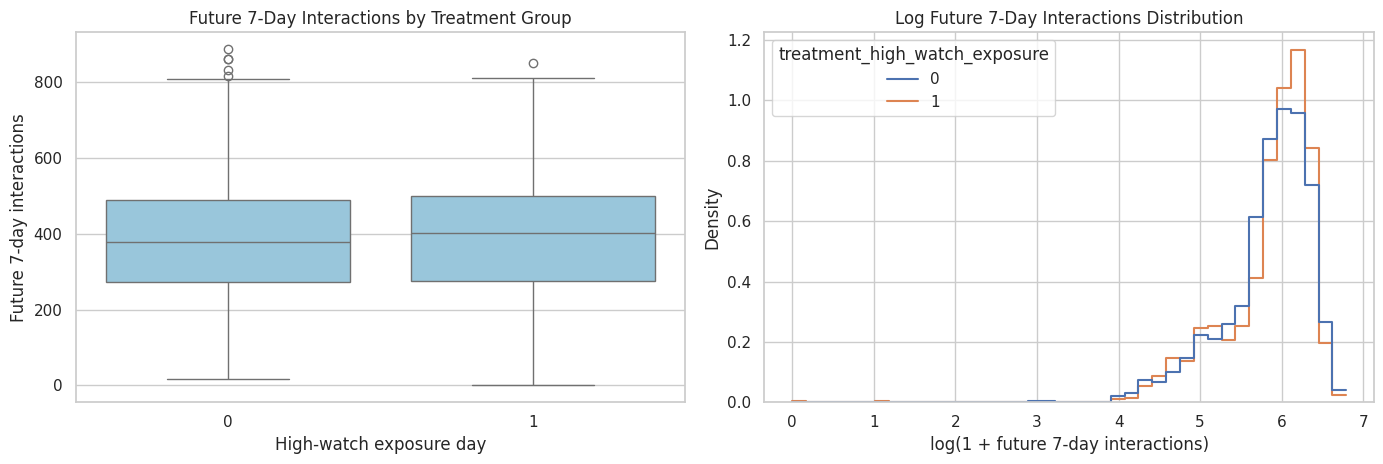

In [21]:
# Visualize the primary outcome by treatment group.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.boxplot(
    data=primary_population,
    x=PRIMARY_TREATMENT,
    y=PRIMARY_OUTCOME,
    ax=axes[0],
    color="#8ECAE6",
)
axes[0].set_title("Future 7-Day Interactions by Treatment Group")
axes[0].set_xlabel("High-watch exposure day")
axes[0].set_ylabel("Future 7-day interactions")

sns.histplot(
    data=primary_population,
    x="log1p_future_7day_interactions",
    hue=PRIMARY_TREATMENT,
    bins=40,
    common_norm=False,
    stat="density",
    element="step",
    fill=False,
    ax=axes[1],
)
axes[1].set_title("Log Future 7-Day Interactions Distribution")
axes[1].set_xlabel("log(1 + future 7-day interactions)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()


The plots show overlap and skew in the selected primary outcome by treatment group. Overlap is important because later causal estimators rely on comparing treated and control observations with similar histories.


### Build the Modeling Table

The modeling table keeps the primary treatment, primary outcome, secondary outcomes, and pre-treatment covariates needed by later notebooks. It also preserves `user_id` and date fields so later models can add user-level clustering, calendar controls, or fixed effects.

The table intentionally excludes post-treatment variables from the covariate list. Future outcomes and same-day treatment labels are included as targets for design checks. Adjustment sets should use pre-treatment information.


In [22]:
# Build the modeling table.
modeling_covariates = [
    "lag_1_active_day",
    "lag_1_interactions",
    "lag_1_total_play_duration_sec",
    "lag_1_avg_watch_ratio",
    "lag_1_high_watch_share",
    "prior_3day_active_day",
    "prior_3day_interactions",
    "prior_3day_total_play_duration_sec",
    "prior_3day_avg_watch_ratio",
    "prior_3day_high_watch_share",
    "calendar_day_index",
    "panel_day_index",
]

modeling_columns = [
    "user_id",
    "event_date",
    "day_of_week",
    "calendar_day_index",
    "panel_day_index",
    "active_day",
    PRIMARY_TREATMENT,
    PRIMARY_OUTCOME,
    *SECONDARY_OUTCOMES,
    *candidate_treatments,
    *modeling_covariates,
]

# Remove duplicates while preserving order because calendar_day_index and panel_day_index appear in multiple roles.
modeling_columns = list(dict.fromkeys(modeling_columns))

estimand_panel = primary_population[modeling_columns].copy()
estimand_panel["treatment"] = estimand_panel[PRIMARY_TREATMENT].astype(int)
estimand_panel["outcome"] = estimand_panel[PRIMARY_OUTCOME].astype(float)
estimand_panel["outcome_log1p"] = np.log1p(estimand_panel["outcome"])
estimand_panel["primary_treatment_name"] = PRIMARY_TREATMENT
estimand_panel["primary_outcome_name"] = PRIMARY_OUTCOME

print(f"Estimand panel shape: {estimand_panel.shape}")
display(estimand_panel.head())


Estimand panel shape: (4698, 30)


,user_id,event_date,day_of_week,calendar_day_index,panel_day_index,active_day,treatment_high_watch_exposure,future_7day_interactions,future_7day_active_days,future_7day_avg_daily_interactions,future_7day_play_hours,log1p_future_7day_interactions,treatment_high_intensity,treatment_overcompletion_exposure,treatment_high_watch_time,lag_1_active_day,lag_1_interactions,lag_1_total_play_duration_sec,lag_1_avg_watch_ratio,lag_1_high_watch_share,prior_3day_active_day,prior_3day_interactions,prior_3day_total_play_duration_sec,prior_3day_avg_watch_ratio,prior_3day_high_watch_share,treatment,outcome,outcome_log1p,primary_treatment_name,primary_outcome_name
3,14,2020-07-08,Wednesday,3,3,1,1,279.0000,7.0000,39.8571,0.7500,5.6348,0,1,0,1.0000,78.0000,655.4890,0.8415,0.4615,3.0000,127.0000,"1,144.8080",2.9900,1.5602,1,279.0000,5.6348,treatment_high_watch_exposure,future_7day_interactions
4,14,2020-07-09,Thursday,4,4,1,0,311.0000,7.0000,44.4286,0.8534,5.7430,0,0,0,1.0000,22.0000,201.9010,0.9828,0.5000,3.0000,123.0000,"1,105.7340",2.8883,1.4833,0,311.0000,5.7430,treatment_high_watch_exposure,future_7day_interactions
5,14,2020-07-10,Friday,5,5,1,1,352.0000,7.0000,50.2857,0.9198,5.8665,0,1,0,1.0000,55.0000,485.0390,0.8619,0.3636,3.0000,155.0000,"1,342.4290",2.6862,1.3252,1,352.0000,5.8665,treatment_high_watch_exposure,future_7day_interactions
6,14,2020-07-11,Saturday,6,6,1,1,437.0000,7.0000,62.4286,1.1297,6.0822,0,0,0,1.0000,52.0000,606.2440,1.1380,0.5769,3.0000,129.0000,"1,293.1840",2.9827,1.4406,1,437.0000,6.0822,treatment_high_watch_exposure,future_7day_interactions
7,14,2020-07-12,Sunday,7,7,1,0,437.0000,7.0000,62.4286,1.1754,6.0822,0,0,0,1.0000,32.0000,284.7470,0.9337,0.5000,3.0000,139.0000,"1,376.0300",2.9336,1.4406,0,437.0000,6.0822,treatment_high_watch_exposure,future_7day_interactions


The modeling table is the operational version of the estimand. It keeps identifiers, the primary treatment and outcome, secondary outcomes, and only pre-treatment covariates needed for adjustment.


#### Final Missingness Check

Before saving, we check missingness for the columns required by later causal models. Missing primary treatment, primary outcome, or covariate values would make downstream estimators fail or silently drop rows.


In [23]:
required_model_columns = ["treatment", "outcome", *modeling_covariates]

final_missingness = (
    estimand_panel[required_model_columns]
    .isna()
    .mean()
    .rename("missing_rate")
    .reset_index()
    .rename(columns={"index": "column"})
    .sort_values("missing_rate", ascending=False)
)

display(final_missingness)

if final_missingness["missing_rate"].max() > 0:
    raise ValueError("The estimand panel has missing values in required model columns.")


,column,missing_rate
0,treatment,0.0000
1,outcome,0.0000
2,lag_1_active_day,0.0000
3,lag_1_interactions,0.0000
4,lag_1_total_play_duration_sec,0.0000
5,lag_1_avg_watch_ratio,0.0000
6,lag_1_high_watch_share,0.0000
7,prior_3day_active_day,0.0000
8,prior_3day_interactions,0.0000
9,prior_3day_total_play_duration_sec,0.0000


The missingness check confirms that required modeling columns are complete. This prevents later causal estimators from silently dropping rows or estimating on a different population than the one defined in this notebook.


In [ ]:
#| include: false
estimand_panel_path = PROCESSED_DIR / "kuairec_long_term_estimand_panel.parquet"
estimand_summary_path = PROCESSED_DIR / "kuairec_long_term_estimand_summary.csv"
treatment_summary_path = PROCESSED_DIR / "kuairec_long_term_candidate_treatments.csv"
outcome_summary_path = PROCESSED_DIR / "kuairec_long_term_candidate_outcomes.csv"
eligibility_funnel_path = PROCESSED_DIR / "kuairec_long_term_eligibility_funnel.csv"

estimand_panel.to_parquet(estimand_panel_path, index=False)
primary_estimand.to_csv(estimand_summary_path, index=False)
treatment_summary.to_csv(treatment_summary_path, index=False)
outcome_summary.to_csv(outcome_summary_path, index=False)
eligibility_funnel.to_csv(eligibility_funnel_path, index=False)

print("Saved Notebook 02 artifacts:")
print(f"- {estimand_panel_path}")
print(f"- {estimand_summary_path}")
print(f"- {treatment_summary_path}")
print(f"- {outcome_summary_path}")
print(f"- {eligibility_funnel_path}")


The saved files are the handoff to formal causal estimation. The parquet file contains the row-level modeling data, while the CSV summaries document the treatment, outcome, and eligibility decisions that produced it.


## Takeaways and Next Step

This notebook defines the primary causal estimand for 

> Among active KuaiRec user-days with sufficient prior history and 7-day follow-up, estimate the effect of a high-watch-exposure day on the user's future 7-day interaction volume.

The selected treatment is more about recommendation quality than raw session size, which makes it a good fit for a long-term recommender-system question. The selected outcome has more variation than binary retention in this sample, while still reflecting future user engagement. Retention-style outcomes remain in the saved panel as secondary checks.

The next notebook should examine **time-varying confounding and treatment assignment** in more detail. That means modeling the probability of treatment from prior user history, checking positivity, and preparing inverse probability weights for a marginal structural model.
